In [4]:
import torch
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np
import sys
sys.path.append('/app')

from src import LigandEnvironment, Receptor, generate_receptor_indices, plot_family_summary,LogNormalConcentration, ExperimentLoader, evaluate_model
from objectives import ExactInformationLoss


# Role of number of samples

In [3]:
loaders = list()
for n in [5,6,7,8,9,10,11,12]:
    loaders.append(ExperimentLoader("/app/data/",experiment_name="batch_"+str(2**n)))

Auto-discovered latest run: batch_32_20260227_143334
Auto-discovered latest run: batch_64_20260227_143407
Auto-discovered latest run: batch_128_20260227_143452
Auto-discovered latest run: batch_256_20260227_143606
Auto-discovered latest run: batch_512_20260227_143721
Auto-discovered latest run: batch_1024_20260227_143840
Auto-discovered latest run: batch_2048_20260227_144002
Auto-discovered latest run: batch_4096_20260227_144201


In [4]:
histories = list()
for loader in loaders:
    histories.append(loader.load_history())

In [5]:
envs, phys, losss,inds,statss,CONFs = [],[],[],[],[],[]
for loader in loaders:
    env, physics, loss_fn, indices, stats, CONF = loader.load_objects("best_model.pt")
    envs.append(env)
    phys.append(physics)
    losss.append(loss_fn)
    inds.append(indices)
    statss.append(stats)
    CONFs.append(CONF)

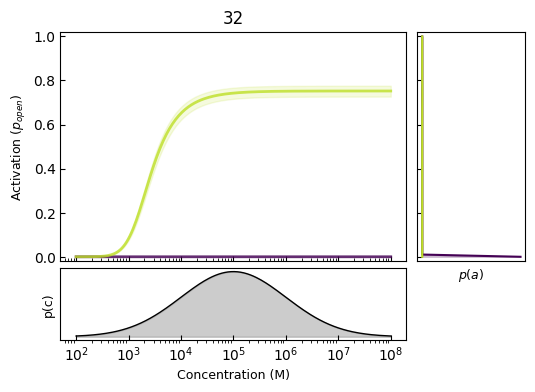

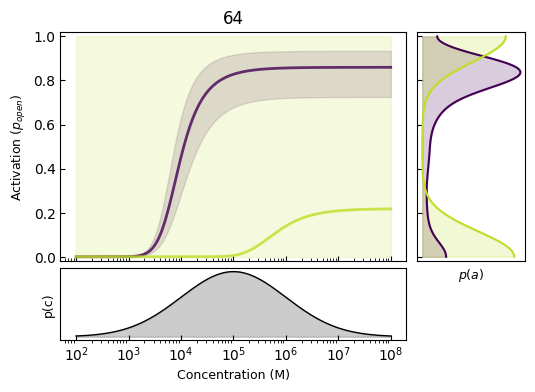

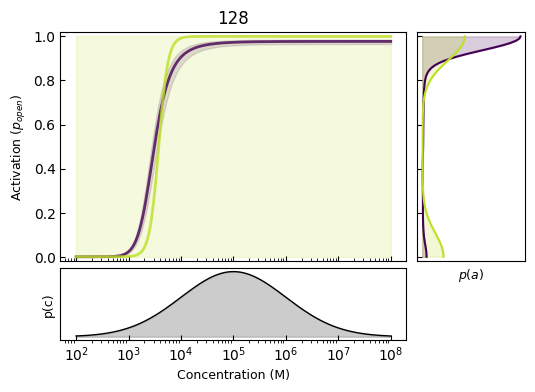

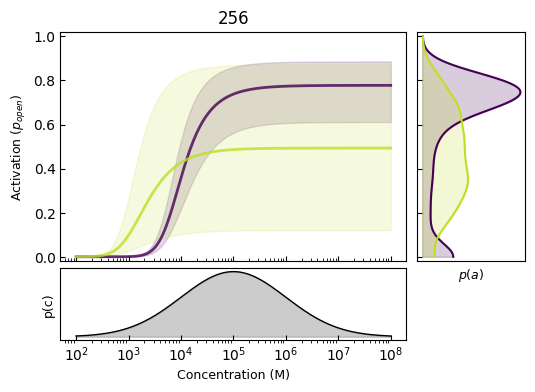

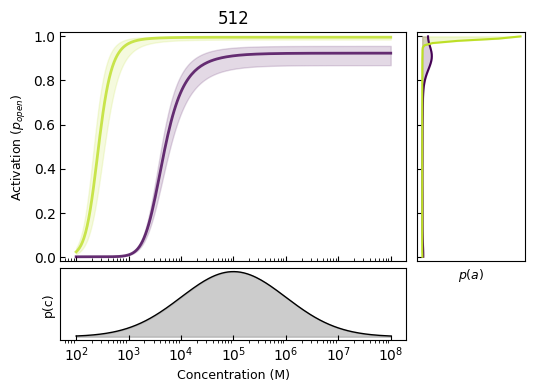

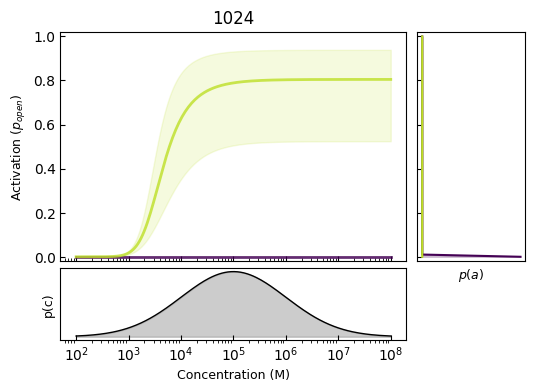

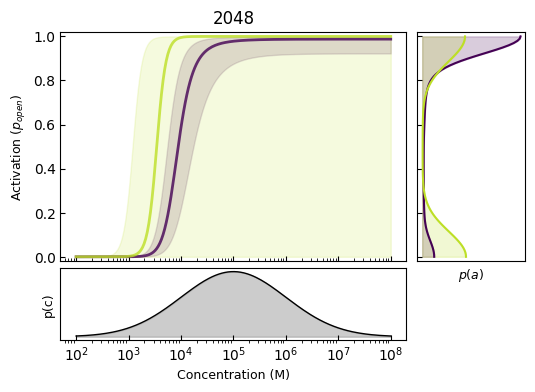

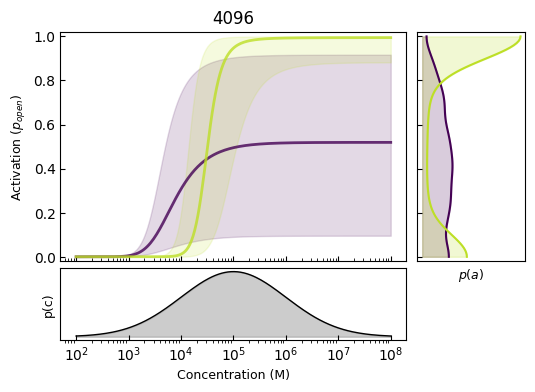

In [6]:
for env,physics,indices,loss_fn,conf in zip(envs,phys,inds,losss,CONFs):
    fig,ax = plot_family_summary(env,physics,indices,loss_fn,n_plot_families=1)
    ax[0][0].set_title(conf['batch_size'])

Text(0.5, 1.0, 'number of famillies = 100')

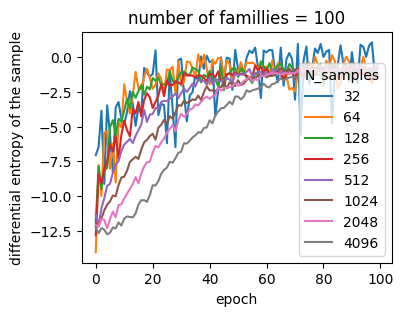

In [7]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
for history_df,conf in zip(histories,CONFs):
    ax.plot(history_df['full_array_entropy'],label=conf['batch_size'])
    ax.set_xlabel('epoch')
    ax.set_ylabel('differential entropy of the sample')
ax.legend(title='N_samples')
ax.set_title(f"number of famillies = {CONFs[0]['n_families']}")
#plt.savefig(f'entropy_minimization_{CONFs[0]["n_families"]}_families.svg',transparent=True,bbox_inches='tight')

In [8]:
ents = []
N = [10,100,1000,10000]
for env,physics,indices,loss_fn in zip(envs,phys,inds,losss):
    # sample a bunch of ligands and store the entropy:
    evaluated_ent = list()
    for n_samples in N:
        ent = list()
        for _ in range(100):
            ent.append(evaluate_model(env=env,physics=physics,receptor_indices=indices,loss_fn=loss_fn,n_samples=n_samples,k_knn=5).item())
        evaluated_ent.append(ent)
    ents.append(evaluated_ent)

Text(0.5, 1.0, 'trained on 32 samples')

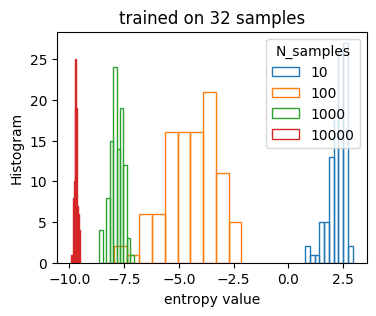

In [9]:

evaluated_ent = ents[0]
fig,ax = plt.subplots(1,1,figsize=(4,3))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = cycle(prop_cycle.by_key()['color'])
for n,ent in zip(N,evaluated_ent):
    ax.hist(ent,fill=False,edgecolor=next(colors),label=f'{n}')
ax.set_xlabel('entropy value')
ax.set_ylabel('Histogram')
ax.legend(title='N_samples')
ax.set_title(f'trained on {CONFs[0]["batch_size"]} samples')
#fig.savefig(f"histogram_test_{CONFs[0]['batch_size']}.svg",transparent=True,bbox_inches='tight')

Text(0.5, 1.0, 'trained on 4096 samples')

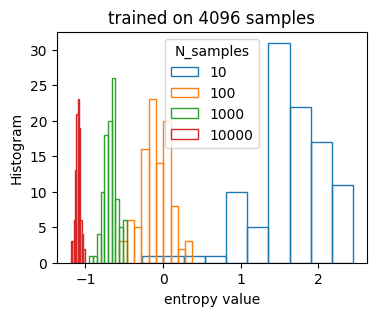

In [10]:
evaluated_ent = ents[-1]
fig,ax = plt.subplots(1,1,figsize=(4,3))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = cycle(prop_cycle.by_key()['color'])
for n,ent in zip(N,evaluated_ent):
    ax.hist(ent,fill=False,edgecolor=next(colors),label=f'{n}')
ax.set_xlabel('entropy value')
ax.set_ylabel('Histogram')
ax.legend(title='N_samples')
ax.set_title(f'trained on {CONFs[-1]["batch_size"]} samples')
#fig.savefig(f"histogram_test_{CONFs[-1]['batch_size']}.svg",transparent=True,bbox_inches='tight')

Text(0.5, 0, 'test batch size')

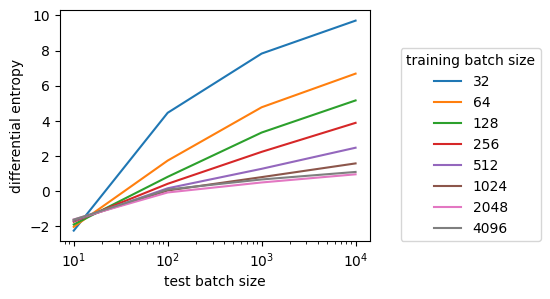

In [12]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
for CONF,evaluated_ent in zip(CONFs,ents):
    #for n,ent in zip(N,evaluated_ent):
    av_ent = np.array([np.mean(ent) for ent in evaluated_ent])
    ax.plot(N,-av_ent,label=CONF["batch_size"])
ax.legend(loc=(1.1,0.),title='training batch size')
ax.set_xscale('log')
ax.set_ylabel('differential entropy')
ax.set_xlabel('test batch size')
#fig.savefig('av_ent_test_sample.svg',transparent=True,bbox_inches='tight')*
 #ax.set_ylim(-1,0.1)